     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00
Mounted at /content/drive
Label counts:
label
0    154
1    159
Name: count, dtype: int64

Sensitive counts:
sensitive
0    230
1     83
Name: count, dtype: int64

=== Group stats (seed=0) ===
train | s=0 count=137  y=1 count=71  y=0 count=66
train | s=1 count=50  y=1 count=24  y=0 count=26
val | s=0 count=46  y=1 count=24  y=0 count=22
val | s=1 count=17  y=1 count=8  y=0 count=9
test | s=0 count=47  y=1 count=24  y=0 count=23
test | s=1 count=16  y=1 count=8  y=0 count=8
seed 0 | test_acc=0.778 | ΔSP=0.096 | ΔEO=0.292 | best_epoch=10
seed 1 | test_acc=0.746 | ΔSP=0.047 | ΔEO=0.042 | best_epoch=5
seed 2 | test_acc=0.651 | ΔSP=0.221 | ΔEO=0.250 | best_epoch=22
seed 3 | test_acc=0.730 | ΔSP=0.049 | ΔEO=0.167 | best_epoch=8
seed 4 | test_acc=0.714 | ΔSP=0.053 | ΔEO=0.167 | best_epoch=19
seed 5 | test_acc=0.587 | ΔSP=0.066 | ΔEO=0.167

,seed,best_epoch,train_acc,val_acc,test_acc,train_dsp,val_dsp,test_dsp,train_deo,val_deo,test_deo,p_intra,p_inter
0,0,10,0.716578,0.777778,0.777778,0.051241,0.134271,0.095745,0.052817,0.083333,0.291667,0.5,0.0
1,1,5,0.689840,0.793651,0.746032,0.079270,0.117021,0.047315,0.015258,0.333333,0.041667,0.5,0.0
2,2,22,0.802139,0.793651,0.650794,0.005255,0.292839,0.220745,0.029930,0.125000,0.250000,0.5,0.0
3,3,8,0.775401,0.761905,0.730159,0.067153,0.031969,0.049202,0.072183,0.083333,0.166667,0.5,0.0
4,4,19,0.786096,0.714286,0.714286,0.054745,0.057545,0.053191,0.150822,0.041667,0.166667,0.5,0.0
5,5,9,0.743316,0.841270,0.587302,0.003942,0.113032,0.066496,0.095070,0.083333,0.166667,0.5,0.0
6,6,8,0.764706,0.746032,0.809524,0.016350,0.066496,0.050532,0.080399,0.125000,0.291667,0.5,0.0
7,7,1,0.705882,0.777778,0.761905,0.033869,0.195479,0.031969,0.026408,0.083333,0.083333,0.5,0.0
8,8,5,0.754011,0.746032,0.666667,0.087737,0.054521,0.075448,0.193075,0.125000,0.083333,0.5,0.0
9,9,12,0.786096,0.730159,0.714286,0.023358,0.168798,0.135638,0.039906,0.166667,0.416667,0.5,0.0



=== FairDrop + GCN on NBA ===
p_intra=0.5, p_inter=0.0
Test Acc: 0.716 ± 0.066
ΔSP     : 0.083 ± 0.057
ΔEO     : 0.196 ± 0.116


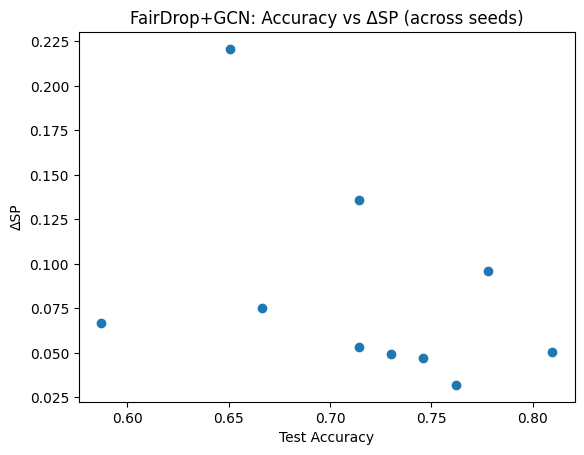

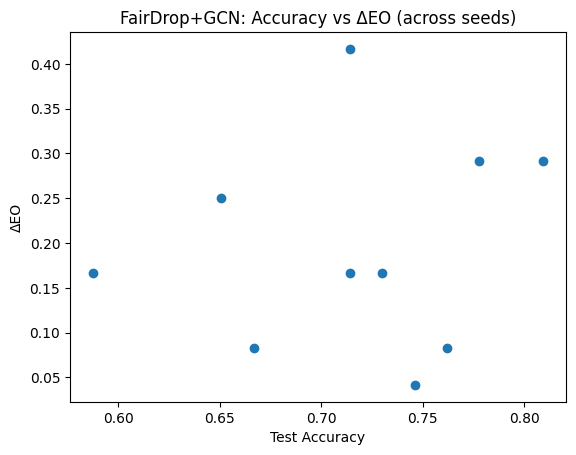


Saved: nba_fairdrop_gcn_results.csv


In [ ]:
# =========================
# 0) Install (Colab)
# =========================
%pip install -q torch torchvision torchaudio
%pip install -q torch-geometric
%pip install -q scikit-learn pandas numpy matplotlib

# =========================
# 1) Imports
# =========================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from google.colab import drive
drive.mount('/content/drive')

# -------------------------
# Repro helper
# -------------------------
def set_global_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# =========================
# 2) Load & preprocess NBA dataset
# =========================
csv_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba.csv"
edge_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba_relationship.txt"

nodes = pd.read_csv(csv_path)

# Drop unknown labels
nodes["SALARY"] = pd.to_numeric(nodes["SALARY"], errors="coerce")
nodes = nodes[nodes["SALARY"].notna() & (nodes["SALARY"] != -1)].copy()

# Label: salary > 0
nodes["label"] = (nodes["SALARY"] > 0).astype(int)

# Sensitive attribute: country (binary)
country = pd.to_numeric(nodes["country"], errors="coerce").fillna(0)
nodes["sensitive"] = (country > 0).astype(int)

feature_cols = [
    c for c in nodes.columns
    if c not in ["user_id", "SALARY", "country", "label", "sensitive"]
]

print("Label counts:")
print(nodes["label"].value_counts().sort_index())
print("\nSensitive counts:")
print(nodes["sensitive"].value_counts().sort_index())

edges = pd.read_csv(edge_path, sep="\t", names=["src", "dst"])

# =========================
# 3) Stratified split masks (stratify by (y, sensitive))
# =========================
def make_stratified_masks(y: torch.Tensor, s: torch.Tensor,
                          train_ratio=0.6, val_ratio=0.2, seed=0):
    y_np = y.cpu().numpy()
    s_np = s.cpu().numpy()
    strata = y_np * 2 + s_np  # 0..3

    idx_all = np.arange(len(y_np))

    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, temp_idx = next(sss1.split(idx_all, strata))

    temp_strata = strata[temp_idx]
    val_size_rel = val_ratio / (1 - train_ratio)

    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_size_rel, random_state=seed)
    val_rel, test_rel = next(sss2.split(temp_idx, temp_strata))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

def print_group_stats(y, s, mask, name):
    y_m = y[mask].cpu().numpy()
    s_m = s[mask].cpu().numpy()
    for sv in [0, 1]:
        idx = (s_m == sv)
        print(f"{name} | s={sv} count={idx.sum()}  y=1 count={(y_m[idx]==1).sum()}  y=0 count={(y_m[idx]==0).sum()}")

# =========================
# 4) Build PyG Data (train-only scaler, undirected edge_index)
# =========================
def build_data(nodes_df: pd.DataFrame, edges_df: pd.DataFrame,
               feature_cols, seed=0):
    y = torch.tensor(nodes_df["label"].values, dtype=torch.long)
    s = torch.tensor(nodes_df["sensitive"].values, dtype=torch.long)

    train_mask, val_mask, test_mask = make_stratified_masks(y, s, seed=seed)

    # Train-only scaler fit (avoid leakage)
    X_np = nodes_df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = X_np.copy()

    train_idx = train_mask.numpy()
    X_scaled[train_idx] = scaler.fit_transform(X_np[train_idx])
    X_scaled[~train_idx] = scaler.transform(X_np[~train_idx])

    X = torch.tensor(X_scaled, dtype=torch.float)

    # Map user_id to 0..N-1
    id_map = {uid: i for i, uid in enumerate(nodes_df["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges_df["src"], edges_df["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    # Make undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    data = Data(x=X, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.sensitive = s
    return data

# =========================
# 5) FairDrop: drop edges based on sensitive-group relation
# =========================
@torch.no_grad()
def (edge_index: torch.Tensor,
                        sensitive: torch.Tensor,
                        p_intra: float = 0.5,
                        p_inter: float = 0.0,
                        generator: torch.Generator | None = None):
    """
    edge_index: [2, E] directed, contains both directions (undirected expanded)
    sensitive: [N] 0/1
    p_intra: drop prob for edges where s(u)==s(v)
    p_inter: drop prob for edges where s(u)!=s(v)
    Return: dropped edge_index (still undirected expanded)
    """
    device = edge_index.device
    s = sensitive.to(device)

    # take undirected unique-ish edges by keeping u < v
    u = edge_index[0]
    v = edge_index[1]
    mask_upper = u < v
    undirected = edge_index[:, mask_upper]  # [2, E_u]

    # (optional) remove duplicate undirected edges
    # torch.unique with dim=1 works for 2xE
    undirected = torch.unique(undirected, dim=1)

    uu = undirected[0]
    vv = undirected[1]

    same_group = (s[uu] == s[vv])  # bool [E_u]
    drop_p = torch.where(same_group,
                         torch.tensor(p_intra, device=device),
                         torch.tensor(p_inter, device=device))

    # random keep mask
    rand = torch.rand(drop_p.size(0), device=device, generator=generator)
    keep = rand > drop_p

    kept = undirected[:, keep]
    # re-expand to directed
    dropped_edge_index = torch.cat([kept, kept.flip(0)], dim=1)
    return dropped_edge_index

# =========================
# 6) Model
# =========================
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class SupervisedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden_dim, dropout=dropout)
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return self.classifier(z)

# =========================
# 7) Metrics
# =========================
@torch.no_grad()
def fairness_metrics(y_true, y_pred, sensitive):
    def safe_mean(mask):
        return y_pred[mask].float().mean() if mask.any() else torch.tensor(float("nan"))

    p1_s0 = safe_mean(sensitive == 0)
    p1_s1 = safe_mean(sensitive == 1)

    tpr_s0 = safe_mean((sensitive == 0) & (y_true == 1))
    tpr_s1 = safe_mean((sensitive == 1) & (y_true == 1))

    delta_sp = torch.abs(p1_s0 - p1_s1)
    delta_eo = torch.abs(tpr_s0 - tpr_s1)
    return float(delta_sp), float(delta_eo)

@torch.no_grad()
def evaluate(model, data, mask, edge_index_for_eval=None):
    """
    eval 默认用原图（不 drop）
    """
    model.eval()
    ei = data.edge_index if edge_index_for_eval is None else edge_index_for_eval
    out = model(data.x, ei)
    pred = out.argmax(dim=1)

    acc = (pred[mask] == data.y[mask]).float().mean().item()
    dsp, deo = fairness_metrics(data.y[mask], pred[mask], data.sensitive[mask])
    return acc, dsp, deo

# =========================
# 8) Train one run (FairDrop + Early stopping on VAL)
# =========================
def train_one_run_fairdrop(data, seed=0, max_epochs=500, patience=50,
                           lr=0.01, weight_decay=5e-4, hidden_dim=64, dropout=0.5,
                           p_intra=0.5, p_inter=0.0):
    set_global_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    model = SupervisedGCN(
        in_channels=data.num_features,
        hidden_dim=hidden_dim,
        num_classes=2,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_state = None
    best_val_acc = -1.0
    best_epoch = 0
    bad = 0

    # generator for FairDrop randomness (deterministic across runs given seed)
    gen = torch.Generator(device=device)
    gen.manual_seed(seed + 12345)

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()

        # change edge_index by FairDrop each epoch (training only)
        # make it epoch-dependent but reproducible:
        gen_epoch = torch.Generator(device=device)
        gen_epoch.manual_seed(seed * 100000 + epoch)

        edge_drop = fairdrop_edge_index(
            data.edge_index, data.sensitive,
            p_intra=p_intra, p_inter=p_inter,
            generator=gen_epoch
        )

        out = model(data.x, edge_drop)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # early stopping on VAL with ORIGINAL graph
        val_acc, _, _ = evaluate(model, data, data.val_mask, edge_index_for_eval=None)

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)

    train_acc, train_sp, train_eo = evaluate(model, data, data.train_mask)
    val_acc, val_sp, val_eo = evaluate(model, data, data.val_mask)
    test_acc, test_sp, test_eo = evaluate(model, data, data.test_mask)

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc,
        "train_dsp": train_sp, "val_dsp": val_sp, "test_dsp": test_sp,
        "train_deo": train_eo, "val_deo": val_eo, "test_deo": test_eo,
        "p_intra": p_intra, "p_inter": p_inter,
    }

# =========================
# 9) Run multi-seed FairDrop+GCN + summary + plots
# =========================
P_INTRA = 0.5
P_INTER = 0.0

seeds = list(range(10))
results = []

for split_seed in seeds:
    data = build_data(nodes, edges, feature_cols, seed=split_seed)

    if split_seed == 0:
        print("\n=== Group stats (seed=0) ===")
        print_group_stats(data.y, data.sensitive, data.train_mask, "train")
        print_group_stats(data.y, data.sensitive, data.val_mask, "val")
        print_group_stats(data.y, data.sensitive, data.test_mask, "test")

    res = train_one_run_fairdrop(
        data, seed=split_seed,
        p_intra=P_INTRA, p_inter=P_INTER
    )
    results.append(res)
    print(f"seed {split_seed} | test_acc={res['test_acc']:.3f} | ΔSP={res['test_dsp']:.3f} | ΔEO={res['test_deo']:.3f} | best_epoch={res['best_epoch']}")

df = pd.DataFrame(results)
display(df)

def mean_std(series):
    return float(series.mean()), float(series.std())

acc_mean, acc_std = mean_std(df["test_acc"])
dsp_mean, dsp_std = mean_std(df["test_dsp"])
deo_mean, deo_std = mean_std(df["test_deo"])

print("\n=== FairDrop + GCN on NBA ===")
print(f"p_intra={P_INTRA}, p_inter={P_INTER}")
print(f"Test Acc: {acc_mean:.3f} ± {acc_std:.3f}")
print(f"ΔSP     : {dsp_mean:.3f} ± {dsp_std:.3f}")
print(f"ΔEO     : {deo_mean:.3f} ± {deo_std:.3f}")

# fairness–accuracy plots across seeds
plt.figure()
plt.scatter(df["test_acc"], df["test_dsp"])
plt.xlabel("Test Accuracy")
plt.ylabel("ΔSP")
plt.title("FairDrop+GCN: Accuracy vs ΔSP (across seeds)")
plt.show()

plt.figure()
plt.scatter(df["test_acc"], df["test_deo"])
plt.xlabel("Test Accuracy")
plt.ylabel("ΔEO")
plt.title("FairDrop+GCN: Accuracy vs ΔEO (across seeds)")
plt.show()

df.to_csv("nba_fairdrop_gcn_results.csv", index=False)
print("\nSaved: nba_fairdrop_gcn_results.csv")


=== Sweep p_intra=0.0, p_inter=0.0 ===
p_intra=0.0 | seed 00 | test_acc=0.762 | ΔSP=0.076 | ΔEO=0.333 | best_epoch=10
p_intra=0.0 | seed 01 | test_acc=0.730 | ΔSP=0.032 | ΔEO=0.042 | best_epoch=6
p_intra=0.0 | seed 02 | test_acc=0.746 | ΔSP=0.052 | ΔEO=0.125 | best_epoch=10
p_intra=0.0 | seed 03 | test_acc=0.714 | ΔSP=0.070 | ΔEO=0.125 | best_epoch=8
p_intra=0.0 | seed 04 | test_acc=0.730 | ΔSP=0.199 | ΔEO=0.167 | best_epoch=27
p_intra=0.0 | seed 05 | test_acc=0.587 | ΔSP=0.066 | ΔEO=0.167 | best_epoch=9
p_intra=0.0 | seed 06 | test_acc=0.810 | ΔSP=0.051 | ΔEO=0.292 | best_epoch=9
p_intra=0.0 | seed 07 | test_acc=0.762 | ΔSP=0.203 | ΔEO=0.167 | best_epoch=10
p_intra=0.0 | seed 08 | test_acc=0.667 | ΔSP=0.082 | ΔEO=0.000 | best_epoch=11
p_intra=0.0 | seed 09 | test_acc=0.714 | ΔSP=0.178 | ΔEO=0.458 | best_epoch=11

=== Sweep p_intra=0.2, p_inter=0.0 ===
p_intra=0.2 | seed 00 | test_acc=0.810 | ΔSP=0.053 | ΔEO=0.292 | best_epoch=10
p_intra=0.2 | seed 01 | test_acc=0.730 | ΔSP=0.026 | ΔE

,seed,best_epoch,train_acc,val_acc,test_acc,train_dsp,val_dsp,test_dsp,train_deo,val_deo,test_deo,p_intra,p_inter
0,0,10,0.727273,0.777778,0.761905,0.000438,0.090793,0.075798,0.011737,0.041667,0.333333,0.0,0.0
1,1,6,0.716578,0.793651,0.730159,0.064964,0.158245,0.031969,0.015845,0.458333,0.041667,0.0,0.0
2,2,10,0.764706,0.793651,0.746032,0.010949,0.094629,0.051862,0.080399,0.166667,0.125000,0.0,0.0
3,3,8,0.780749,0.761905,0.714286,0.114453,0.031969,0.070479,0.113850,0.083333,0.125000,0.0,0.0
4,4,27,0.823529,0.730159,0.730159,0.022044,0.035806,0.199468,0.165493,0.041667,0.166667,0.0,0.0


,p_intra,p_inter,test_acc_mean,test_acc_std,test_dsp_mean,test_dsp_std,test_deo_mean,test_deo_std,best_epoch_mean
0,0.0,0.0,0.722222,0.060443,0.100996,0.065808,0.187500,0.137843,11.1
1,0.2,0.0,0.715873,0.066696,0.083902,0.048389,0.187500,0.127672,11.2
2,0.4,0.0,0.717460,0.056888,0.085371,0.044344,0.187500,0.121478,11.2
3,0.6,0.0,0.706349,0.048058,0.085426,0.060295,0.191667,0.113175,15.3
4,0.8,0.0,0.701587,0.050083,0.096054,0.059844,0.212500,0.143601,15.5



Saved: nba_fairdrop_sweep_all.csv
Saved: nba_fairdrop_sweep_summary.csv


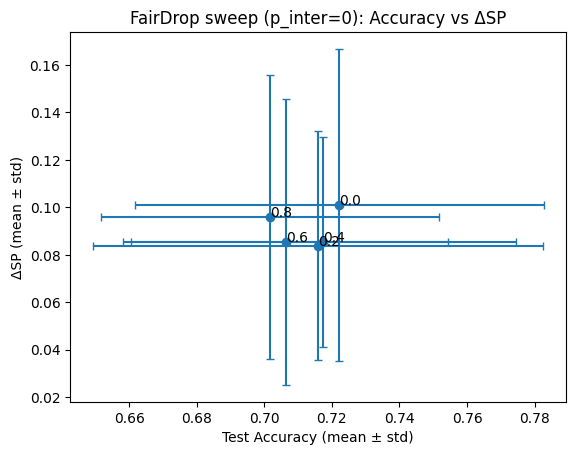

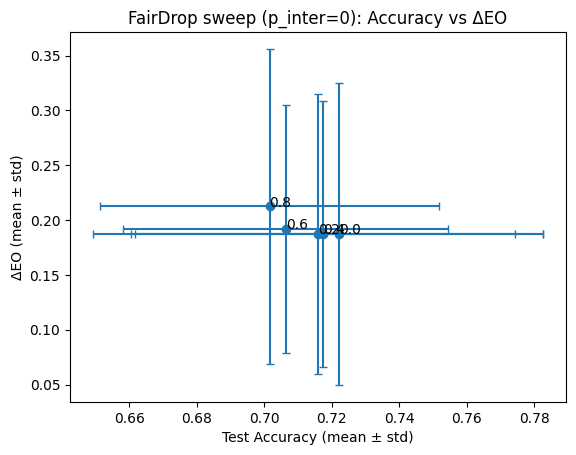

In [ ]:
# =========================
# 10) FairDrop sweep (p_intra grid, p_inter fixed)
#     Run this AFTER your FairDrop+GCN code above
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# reuse seeds if already defined; otherwise default to 10 seeds
try:
    seeds
except NameError:
    seeds = list(range(10))

P_INTER = 0.0
p_intra_grid = [0.0, 0.2, 0.4, 0.6, 0.8]

all_rows = []

for p_intra in p_intra_grid:
    print(f"\n=== Sweep p_intra={p_intra}, p_inter={P_INTER} ===")
    for sd in seeds:
        data = build_data(nodes, edges, feature_cols, seed=sd)

        res = train_one_run_fairdrop(
            data,
            seed=sd,
            p_intra=p_intra,
            p_inter=P_INTER
        )
        all_rows.append(res)

        print(
            f"p_intra={p_intra:.1f} | seed {sd:02d} | "
            f"test_acc={res['test_acc']:.3f} | ΔSP={res['test_dsp']:.3f} | ΔEO={res['test_deo']:.3f} | "
            f"best_epoch={res['best_epoch']}"
        )

df_all = pd.DataFrame(all_rows)
display(df_all.head())

# summary table: mean±std per p_intra
summary = (
    df_all.groupby(["p_intra", "p_inter"])
    .agg(
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_dsp_mean=("test_dsp", "mean"),
        test_dsp_std=("test_dsp", "std"),
        test_deo_mean=("test_deo", "mean"),
        test_deo_std=("test_deo", "std"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .reset_index()
    .sort_values("p_intra")
)

display(summary)

# save csv
df_all.to_csv("nba_fairdrop_sweep_all.csv", index=False)
summary.to_csv("nba_fairdrop_sweep_summary.csv", index=False)
print("\nSaved: nba_fairdrop_sweep_all.csv")
print("Saved: nba_fairdrop_sweep_summary.csv")

# =========================
# 11) Plot trade-off curves (mean ± std)
# =========================
x = summary["test_acc_mean"].values
xerr = summary["test_acc_std"].values

# Acc vs ΔSP
y_dsp = summary["test_dsp_mean"].values
yerr_dsp = summary["test_dsp_std"].values

plt.figure()
plt.errorbar(x, y_dsp, xerr=xerr, yerr=yerr_dsp, fmt='o', capsize=3)
for i, p in enumerate(summary["p_intra"].values):
    plt.annotate(f"{p:.1f}", (x[i], y_dsp[i]))
plt.xlabel("Test Accuracy (mean ± std)")
plt.ylabel("ΔSP (mean ± std)")
plt.title("FairDrop sweep (p_inter=0): Accuracy vs ΔSP")
plt.show()

# Acc vs ΔEO
y_deo = summary["test_deo_mean"].values
yerr_deo = summary["test_deo_std"].values

plt.figure()
plt.errorbar(x, y_deo, xerr=xerr, yerr=yerr_deo, fmt='o', capsize=3)
for i, p in enumerate(summary["p_intra"].values):
    plt.annotate(f"{p:.1f}", (x[i], y_deo[i]))
plt.xlabel("Test Accuracy (mean ± std)")
plt.ylabel("ΔEO (mean ± std)")
plt.title("FairDrop sweep (p_inter=0): Accuracy vs ΔEO")
plt.show()

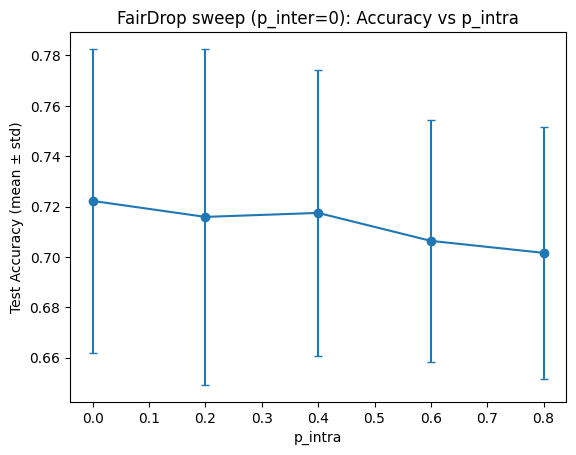

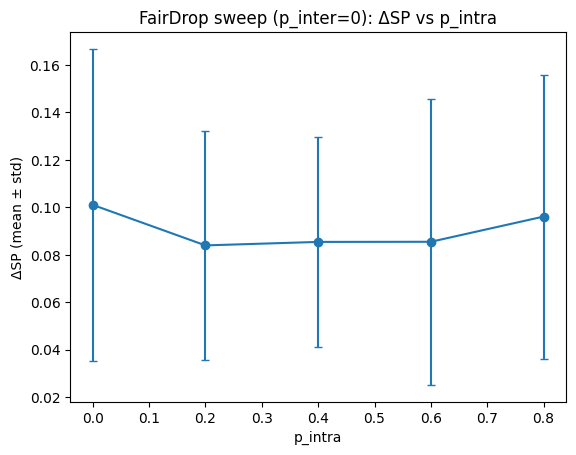

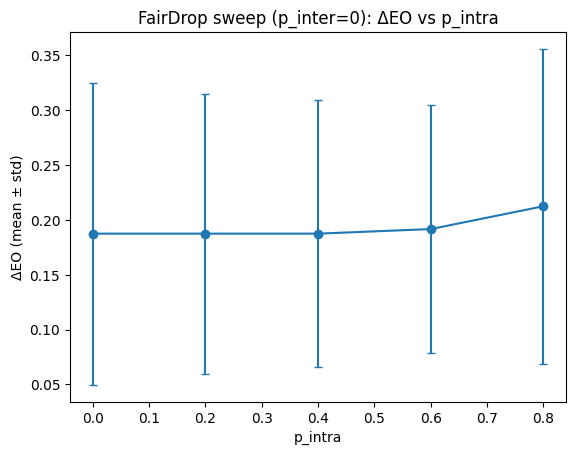

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(summary["p_intra"], summary["test_acc_mean"],
             yerr=summary["test_acc_std"], fmt="o-", capsize=3)
plt.xlabel("p_intra")
plt.ylabel("Test Accuracy (mean ± std)")
plt.title("FairDrop sweep (p_inter=0): Accuracy vs p_intra")
plt.show()

plt.figure()
plt.errorbar(summary["p_intra"], summary["test_dsp_mean"],
             yerr=summary["test_dsp_std"], fmt="o-", capsize=3)
plt.xlabel("p_intra")
plt.ylabel("ΔSP (mean ± std)")
plt.title("FairDrop sweep (p_inter=0): ΔSP vs p_intra")
plt.show()

plt.figure()
plt.errorbar(summary["p_intra"], summary["test_deo_mean"],
             yerr=summary["test_deo_std"], fmt="o-", capsize=3)
plt.xlabel("p_intra")
plt.ylabel("ΔEO (mean ± std)")
plt.title("FairDrop sweep (p_inter=0): ΔEO vs p_intra")
plt.show()

In [ ]:
# ===== Paired difference + bootstrap CI =====
import numpy as np
import pandas as pd

# baseline at p_intra=0.0
base = df_all[df_all["p_intra"] == 0.0].sort_values("seed")

def bootstrap_ci(diffs, B=20000, seed=0):
    diffs = np.asarray(diffs)
    rng = np.random.default_rng(seed)
    n = len(diffs)
    idx = rng.integers(0, n, size=(B, n))
    boot = diffs[idx].mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))

rows = []
for p in sorted(df_all["p_intra"].unique()):
    cur = df_all[df_all["p_intra"] == p].sort_values("seed")

    # align by seed (important!)
    assert (cur["seed"].values == base["seed"].values).all()

    d_acc = cur["test_acc"].values - base["test_acc"].values
    d_dsp = cur["test_dsp"].values - base["test_dsp"].values
    d_deo = cur["test_deo"].values - base["test_deo"].values

    rows.append({
        "p_intra": p,
        "mean(ΔAcc)": float(d_acc.mean()),
        "CI95(ΔAcc)": bootstrap_ci(d_acc),
        "mean(ΔΔSP)": float(d_dsp.mean()),
        "CI95(ΔΔSP)": bootstrap_ci(d_dsp),
        "mean(ΔΔEO)": float(d_deo.mean()),
        "CI95(ΔΔEO)": bootstrap_ci(d_deo),
    })

paired_summary = pd.DataFrame(rows).sort_values("p_intra")
display(paired_summary)

,p_intra,mean(ΔAcc),CI95(ΔAcc),mean(ΔΔSP),CI95(ΔΔSP),mean(ΔΔEO),CI95(ΔΔEO)
0,0.0,0.000000,"(0.0, 0.0)",0.000000,"(0.0, 0.0)",0.000000e+00,"(0.0, 0.0)"
1,0.2,-0.006349,"(-0.030158734321594237, 0.014285707473754882)",-0.017094,"(-0.04326306462287903, 0.011368492245674133)",-5.960464e-09,"(-0.0375, 0.03749999403953552)"
2,0.4,-0.004762,"(-0.023809528350830077, 0.01111111044883728)",-0.015626,"(-0.038799864053726194, 0.007948546558618479)",-5.960464e-09,"(-0.041666668653488156, 0.03749999403953552)"
3,0.6,-0.015873,"(-0.038095253705978396, 0.004761892557144165)",-0.015570,"(-0.0646903458237648, 0.034967619180679324)",4.166657e-03,"(-0.037499988228082655, 0.045833319425582886)"
4,0.8,-0.020635,"(-0.04761906862258911, 0.006349200010299682)",-0.004942,"(-0.05240430809557438, 0.04754519455134856)",2.499999e-02,"(-0.06250001788139344, 0.1)"
